# 02 - Store Sales Forecasting - Metrics and Error Analysis

## Objective

Analyze the corrected LightGBM baseline using a temporally consistent pipeline.

Main goals:
- evaluate the baseline with multiple regression metrics
- analyze prediction errors across time and business dimensions
- identify systematic weaknesses of the model
- generate insights to guide the next feature engineering step

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_squared_log_error
)

In [2]:
SEED = 42
DATA_DIR = Path("../data")
TARGET = "sales"
USE_FULL_DATA = False
LAST_N_DAYS = 365

print("Setup OK")
print("Data dir:", DATA_DIR.resolve())

Setup OK
Data dir: /home/donatocorbacio/projects/store-sales-project/data


## Load data

Load the Store Sales dataset and inspect its structure.

In [3]:
train = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["date"])
test = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["date"])

print("Train shape:", train.shape)
print("Test shape:", test.shape)

display(train.head())

Train shape: (3000888, 6)
Test shape: (28512, 5)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [4]:
print("Train range:", train["date"].min(), "->", train["date"].max())
print("Test range:", test["date"].min(), "->", test["date"].max())

Train range: 2013-01-01 00:00:00 -> 2017-08-15 00:00:00
Test range: 2017-08-16 00:00:00 -> 2017-08-31 00:00:00


## Rebuild corrected baseline pipeline

Recreate the same technically correct baseline pipeline used in NB1.

This ensures that all metrics and error analyses are based on:
- chronologically ordered store-family series
- consistent lag features
- temporal validation without leakage

In [5]:
train = train.sort_values(["store_nbr", "family", "date"]).copy()
test = test.sort_values(["store_nbr", "family", "date"]).copy()

print("Sorting completed.")
display(train.head())

Sorting completed.


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1782,1782,2013-01-02,1,AUTOMOTIVE,2.0,0
3564,3564,2013-01-03,1,AUTOMOTIVE,3.0,0
5346,5346,2013-01-04,1,AUTOMOTIVE,3.0,0
7128,7128,2013-01-05,1,AUTOMOTIVE,5.0,0


In [6]:
if not USE_FULL_DATA:
    cutoff_date = train["date"].max() - pd.Timedelta(days=LAST_N_DAYS)
    train = train[train["date"] >= cutoff_date].copy()
    print(f"Using temporal subset: last {LAST_N_DAYS} days")
    print("Cutoff date:", cutoff_date)
else:
    print("Using full dataset")

print("Train shape after temporal selection:", train.shape)
print("New date range:", train["date"].min(), "->", train["date"].max())

Using temporal subset: last 365 days
Cutoff date: 2016-08-15 00:00:00
Train shape after temporal selection: (650430, 6)
New date range: 2016-08-15 00:00:00 -> 2017-08-15 00:00:00


## Time-based features

Create the same basic calendar features used in the baseline.

In [7]:
for df in [train, test]:
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)

display(train[["date", "year", "month", "day", "dayofweek", "weekofyear"]].head())

,date,year,month,day,dayofweek,weekofyear
2350458,2016-08-15,2016,8,15,0,33
2352240,2016-08-16,2016,8,16,1,33
2354022,2016-08-17,2016,8,17,2,33
2355804,2016-08-18,2016,8,18,3,33
2357586,2016-08-19,2016,8,19,4,33


## Lag features

Create lag_1 and lag_7 for each (store_nbr, family) time series.

In [8]:
group_cols = ["store_nbr", "family"]

train["lag_1"] = train.groupby(group_cols)[TARGET].shift(1)
train["lag_7"] = train.groupby(group_cols)[TARGET].shift(7)

display(train[["date", "store_nbr", "family", "sales", "lag_1", "lag_7"]].head(15))

,date,store_nbr,family,sales,lag_1,lag_7
2350458,2016-08-15,1,AUTOMOTIVE,4.0,NaN,NaN
2352240,2016-08-16,1,AUTOMOTIVE,5.0,4.0,NaN
2354022,2016-08-17,1,AUTOMOTIVE,4.0,5.0,NaN
2355804,2016-08-18,1,AUTOMOTIVE,6.0,4.0,NaN
2357586,2016-08-19,1,AUTOMOTIVE,12.0,6.0,NaN
2359368,2016-08-20,1,AUTOMOTIVE,6.0,12.0,NaN
2361150,2016-08-21,1,AUTOMOTIVE,0.0,6.0,NaN
2362932,2016-08-22,1,AUTOMOTIVE,2.0,0.0,4.0
2364714,2016-08-23,1,AUTOMOTIVE,3.0,2.0,5.0
2366496,2016-08-24,1,AUTOMOTIVE,8.0,3.0,4.0


In [9]:
train = train.dropna(subset=["lag_1", "lag_7"]).copy()

print("Train shape after lag cleaning:", train.shape)
display(train.head())

Train shape after lag cleaning: (637956, 13)


,id,date,store_nbr,family,sales,onpromotion,year,month,day,dayofweek,weekofyear,lag_1,lag_7
2362932,2362932,2016-08-22,1,AUTOMOTIVE,2.0,0,2016,8,22,0,34,0.0,4.0
2364714,2364714,2016-08-23,1,AUTOMOTIVE,3.0,0,2016,8,23,1,34,2.0,5.0
2366496,2366496,2016-08-24,1,AUTOMOTIVE,8.0,0,2016,8,24,2,34,3.0,4.0
2368278,2368278,2016-08-25,1,AUTOMOTIVE,2.0,0,2016,8,25,3,34,8.0,6.0
2370060,2370060,2016-08-26,1,AUTOMOTIVE,7.0,0,2016,8,26,4,34,2.0,12.0


## Encoding

Encode the family categorical variable into numeric codes.

In [10]:
train["family"] = train["family"].astype("category")
test["family"] = test["family"].astype("category")

family_mapping = dict(enumerate(train["family"].cat.categories))

train["family"] = train["family"].cat.codes
test["family"] = test["family"].cat.codes

print("Family encoding completed.")
print("Number of encoded families:", len(family_mapping))

Family encoding completed.
Number of encoded families: 33


In [11]:
features = [
    "store_nbr",
    "family",
    "onpromotion",
    "year",
    "month",
    "day",
    "dayofweek",
    "weekofyear",
    "lag_1",
    "lag_7",
]

X = train[features]
y = train[TARGET]

print("Selected features:")
print(features)
print("X shape:", X.shape)
print("y shape:", y.shape)

Selected features:
['store_nbr', 'family', 'onpromotion', 'year', 'month', 'day', 'dayofweek', 'weekofyear', 'lag_1', 'lag_7']
X shape: (637956, 10)
y shape: (637956,)


## Train / validation split

Use a chronological split to preserve temporal order.

In [12]:
split_date = train["date"].quantile(0.8)

train_data = train[train["date"] < split_date].copy()
val_data = train[train["date"] >= split_date].copy()

X_train = train_data[features]
y_train = train_data[TARGET]

X_val = val_data[features]
y_val = val_data[TARGET]

print("Split date:", split_date)
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Train date range:", train_data["date"].min(), "->", train_data["date"].max())
print("Val date range:", val_data["date"].min(), "->", val_data["date"].max())

Split date: 2017-06-05 00:00:00
Train shape: (509652, 10)
Validation shape: (128304, 10)
Train date range: 2016-08-22 00:00:00 -> 2017-06-04 00:00:00
Val date range: 2017-06-05 00:00:00 -> 2017-08-15 00:00:00


## Model training

Train the same LightGBM baseline used in NB1.

In [13]:
model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training completed.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003626 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 924
[LightGBM] [Info] Number of data points in the train set: 509652, number of used features: 10
[LightGBM] [Info] Start training from score 472.846958
Model training completed.


In [14]:
y_pred = model.predict(X_val)
y_pred = np.clip(y_pred, 0, None)

print("First predictions:", y_pred[:10])

First predictions: [3.56760568 5.95386657 4.12980225 5.05563394 4.83000755 4.12810499
 4.84898827 3.29496974 4.79043943 4.99761736]


## Global evaluation metrics

Evaluate the baseline using multiple regression metrics.

Main metric:
- RMSLE

Additional supporting metrics:
- MAE
- RMSE
- R²

In [15]:
rmsle = np.sqrt(mean_squared_log_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("Validation RMSLE:", rmsle)
print("Validation MAE:", mae)
print("Validation RMSE:", rmse)
print("Validation R²:", r2)

Validation RMSLE: 0.7823800132116003
Validation MAE: 67.39812010590542
Validation RMSE: 239.97491107773425
Validation R²: 0.9662859503926585


## Error analysis dataset

Create a validation results table to inspect predictions and errors.

In [16]:
results = val_data[[
    "date",
    "store_nbr",
    "family",
    "dayofweek",
    "month",
    "sales",
    "lag_1",
    "lag_7",
    "onpromotion"
]].copy()

results["y_pred"] = y_pred
results["error"] = results["sales"] - results["y_pred"]
results["abs_error"] = np.abs(results["error"])
results["squared_error"] = results["error"] ** 2
results["is_weekend"] = results["dayofweek"].isin([5, 6]).astype(int)

display(results.head())

,date,store_nbr,family,dayofweek,month,sales,lag_1,lag_7,onpromotion,y_pred,error,abs_error,squared_error,is_weekend
2872584,2017-06-05,1,0,0,6,6.0,0.0,6.0,0,3.567606,2.432394,2.432394,5.916542,0
2874366,2017-06-06,1,0,1,6,2.0,6.0,2.0,0,5.953867,-3.953867,3.953867,15.633061,0
2876148,2017-06-07,1,0,2,6,7.0,2.0,3.0,0,4.129802,2.870198,2.870198,8.238035,0
2877930,2017-06-08,1,0,3,6,1.0,7.0,6.0,0,5.055634,-4.055634,4.055634,16.448167,0
2879712,2017-06-09,1,0,4,6,1.0,1.0,19.0,0,4.830008,-3.830008,3.830008,14.668958,0


## True vs predicted

Visualize how predictions relate to the true sales values.

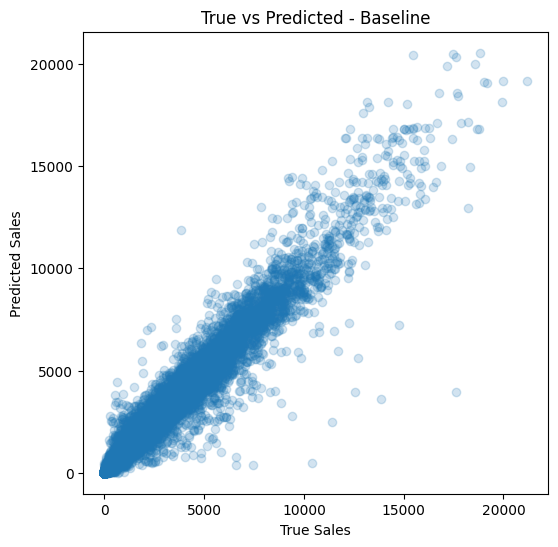

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(results["sales"], results["y_pred"], alpha=0.2)
plt.xlabel("True Sales")
plt.ylabel("Predicted Sales")
plt.title("True vs Predicted - Baseline")
plt.show()

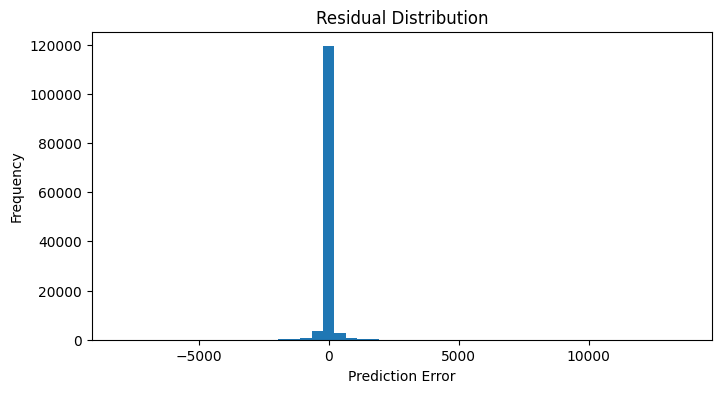

In [18]:
plt.figure(figsize=(8, 4))
plt.hist(results["error"], bins=50)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

## Error by day of week

Check whether the model behaves differently across weekdays and weekends.

In [19]:
error_by_dayofweek = (
    results.groupby("dayofweek")
    .agg(
        mean_abs_error=("abs_error", "mean"),
        mean_error=("error", "mean"),
        count=("error", "size")
    )
    .sort_index()
)

display(error_by_dayofweek)

,mean_abs_error,mean_error,count
dayofweek,,,
0,64.592626,1.203606,19602
1,57.931960,-0.454396,19602
2,56.437987,-1.761454,17820
3,55.744803,-6.488894,17820
4,64.226801,2.827589,17820
5,80.394433,-14.396989,17820
6,93.685396,-33.608271,17820


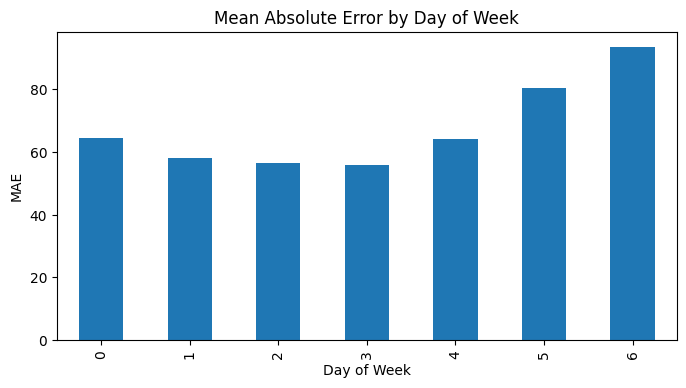

In [20]:
plt.figure(figsize=(8, 4))
error_by_dayofweek["mean_abs_error"].plot(kind="bar")
plt.title("Mean Absolute Error by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("MAE")
plt.show()

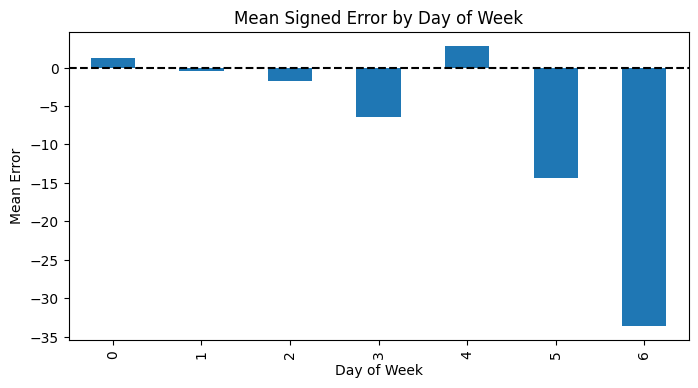

In [21]:
plt.figure(figsize=(8, 4))
error_by_dayofweek["mean_error"].plot(kind="bar")
plt.title("Mean Signed Error by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Mean Error")
plt.axhline(0, color="black", linestyle="--")
plt.show()

In [22]:
error_weekend = (
    results.groupby("is_weekend")
    .agg(
        mean_abs_error=("abs_error", "mean"),
        mean_error=("error", "mean"),
        count=("error", "size")
    )
)

error_weekend.index = ["Weekday", "Weekend"]
display(error_weekend)

,mean_abs_error,mean_error,count
Weekday,59.843584,-0.884351,92664
Weekend,87.039914,-24.002630,35640


In [23]:
error_by_month = (
    results.groupby("month")
    .agg(
        mean_abs_error=("abs_error", "mean"),
        mean_error=("error", "mean"),
        count=("error", "size")
    )
    .sort_index()
)

display(error_by_month)

,mean_abs_error,mean_error,count
month,,,
6,66.121573,-5.983725,46332
7,63.937565,-2.244782,55242
8,76.762616,-20.058252,26730


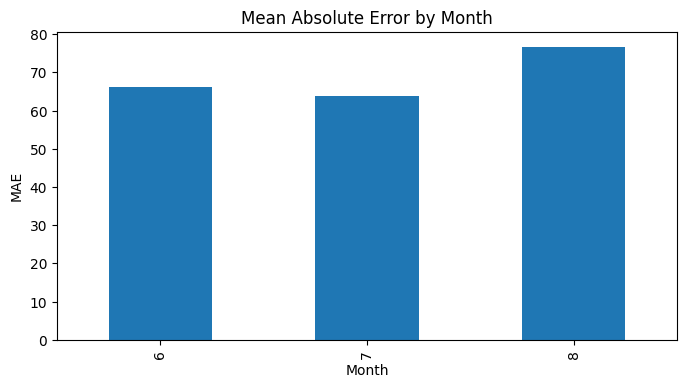

In [24]:
plt.figure(figsize=(8, 4))
error_by_month["mean_abs_error"].plot(kind="bar")
plt.title("Mean Absolute Error by Month")
plt.xlabel("Month")
plt.ylabel("MAE")
plt.show()

## Error by store

Identify stores where the model performs worst.

In [25]:
error_by_store = (
    results.groupby("store_nbr")
    .agg(
        mean_abs_error=("abs_error", "mean"),
        mean_error=("error", "mean"),
        mean_sales=("sales", "mean"),
        count=("error", "size")
    )
    .sort_values("mean_abs_error", ascending=False)
)

display(error_by_store.head(10))

,mean_abs_error,mean_error,mean_sales,count
store_nbr,,,,
44,138.215400,-15.610157,1351.390253,2376
47,132.767273,-23.697799,1155.433890,2376
45,122.294764,-11.041060,1246.335166,2376
46,114.457299,-27.252104,924.765354,2376
3,107.438478,-16.379913,1103.903126,2376
49,103.994974,-25.807245,1056.775452,2376
39,99.251915,-3.030304,508.795599,2376
48,98.891345,-18.180896,761.157827,2376
40,93.593919,9.196740,488.558537,2376


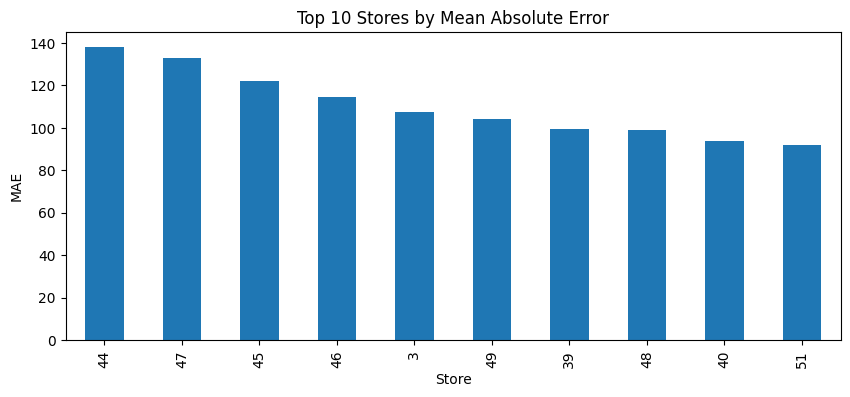

In [26]:
plt.figure(figsize=(10, 4))
error_by_store["mean_abs_error"].head(10).plot(kind="bar")
plt.title("Top 10 Stores by Mean Absolute Error")
plt.xlabel("Store")
plt.ylabel("MAE")
plt.show()

## Error by family

Identify product families where the model struggles most.

In [27]:
results["family_name"] = results["family"].map(family_mapping)

error_by_family = (
    results.groupby("family_name")
    .agg(
        mean_abs_error=("abs_error", "mean"),
        mean_error=("error", "mean"),
        mean_sales=("sales", "mean"),
        count=("error", "size")
    )
    .sort_values("mean_abs_error", ascending=False)
)

display(error_by_family.head(10))

,mean_abs_error,mean_error,mean_sales,count
family_name,,,,
GROCERY I,526.821700,-79.108257,4604.061662,3888
BEVERAGES,500.301807,-12.988949,3555.751800,3888
CLEANING,262.744615,-34.420675,1268.404064,3888
PRODUCE,243.009348,-20.298182,2365.205327,3888
DAIRY,99.789887,-36.674360,886.793724,3888
MEATS,72.564118,-9.884089,377.509100,3888
BREAD/BAKERY,64.443638,3.889726,547.272785,3888
PERSONAL CARE,59.499259,-10.012378,313.079218,3888
POULTRY,58.680324,0.860270,390.245256,3888


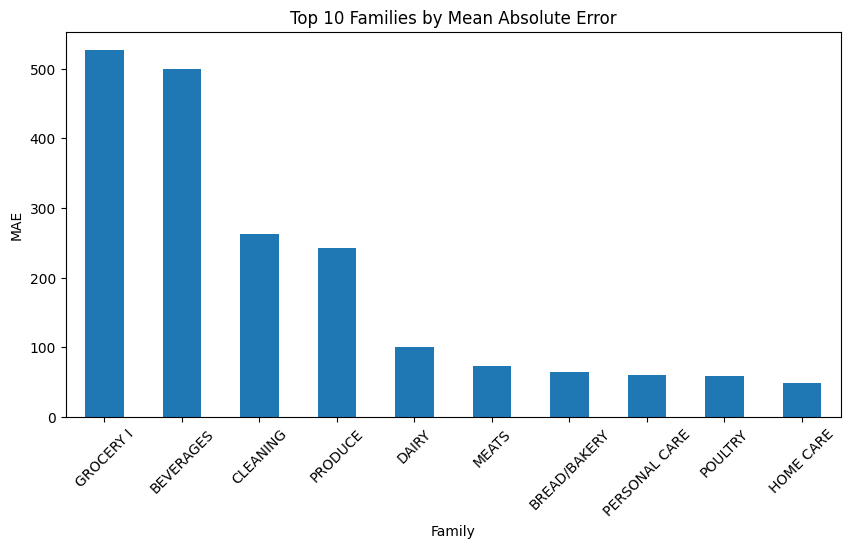

In [28]:
plt.figure(figsize=(10, 5))
error_by_family["mean_abs_error"].head(10).plot(kind="bar")
plt.title("Top 10 Families by Mean Absolute Error")
plt.xlabel("Family")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.show()

## Worst predictions

Inspect the largest prediction errors to identify failure patterns.

In [29]:
worst_predictions = results.sort_values("abs_error", ascending=False).head(20)

display(
    worst_predictions[[
        "date",
        "store_nbr",
        "family_name",
        "sales",
        "y_pred",
        "error",
        "abs_error",
        "dayofweek",
        "lag_1",
        "lag_7",
        "onpromotion"
    ]]
)

,date,store_nbr,family_name,sales,y_pred,error,abs_error,dayofweek,lag_1,lag_7,onpromotion
2909844,2017-06-25,54,BEVERAGES,17614.0,3949.391700,13664.608300,13664.608300,6,2043.0,8310.0,30
2884896,2017-06-11,54,BEVERAGES,13889.0,3587.076021,10301.923979,10301.923979,6,2426.0,4605.0,26
2935720,2017-07-10,30,CLEANING,10392.0,483.995769,9908.004231,9908.004231,0,462.0,548.0,23
2874204,2017-06-05,54,BEVERAGES,11428.0,2467.714184,8960.285816,8960.285816,0,4605.0,1770.0,32
2896776,2017-06-18,38,BEVERAGES,12571.0,3929.810448,8641.189552,8641.189552,6,3351.0,3651.0,22
2922318,2017-07-02,54,BEVERAGES,3833.0,11873.578073,-8040.578073,8040.578073,6,7309.0,17614.0,33
2900670,2017-06-20,47,BEVERAGES,14764.0,7236.003075,7527.996925,7527.996925,1,7283.0,8065.0,29
2944890,2017-07-15,38,BEVERAGES,12734.0,5618.520169,7115.479831,7115.479831,5,9425.0,3122.0,46
2928658,2017-07-06,32,CLEANING,7435.0,390.231328,7044.768672,7044.768672,3,309.0,363.0,25
2943108,2017-07-14,38,BEVERAGES,9425.0,2753.092083,6671.907917,6671.907917,4,2815.0,2144.0,35


## Daily error trend

Aggregate errors by date to check whether some periods are more difficult.

In [30]:
daily_error = (
    results.groupby("date")
    .agg(
        mean_abs_error=("abs_error", "mean"),
        mean_error=("error", "mean")
    )
    .reset_index()
)

display(daily_error.head())

,date,mean_abs_error,mean_error
0,2017-06-05,76.295083,6.303853
1,2017-06-06,58.679588,-2.896305
2,2017-06-07,66.320762,3.560063
3,2017-06-08,56.898935,-6.702205
4,2017-06-09,59.183788,1.700104


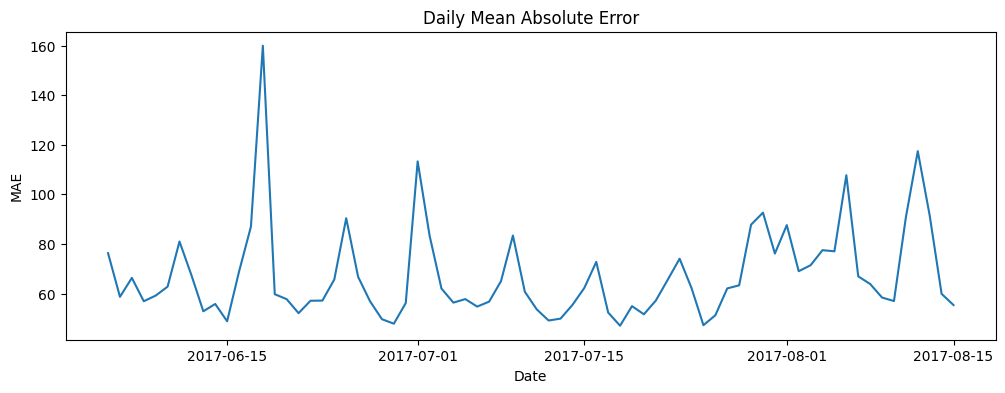

In [31]:
plt.figure(figsize=(12, 4))
plt.plot(daily_error["date"], daily_error["mean_abs_error"])
plt.title("Daily Mean Absolute Error")
plt.xlabel("Date")
plt.ylabel("MAE")
plt.show()

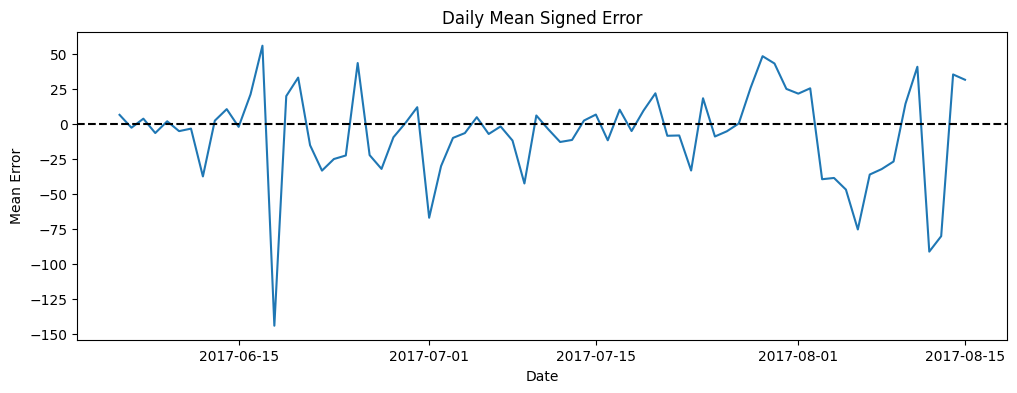

In [32]:
plt.figure(figsize=(12, 4))
plt.plot(daily_error["date"], daily_error["mean_error"])
plt.axhline(0, color="black", linestyle="--")
plt.title("Daily Mean Signed Error")
plt.xlabel("Date")
plt.ylabel("Mean Error")
plt.show()

## Key findings

Main findings from the baseline error analysis:

- the baseline performs worse on weekends than on weekdays
- some stores show systematically higher error than others
- some product families are more difficult to predict
- the model tends to smooth some high-value cases
- these results suggest that the next step should focus on richer temporal and aggregated features

## Conclusion

This notebook evaluates the corrected LightGBM baseline using multiple regression metrics and detailed error analysis.

Main outcomes:
- the baseline is evaluated on a technically correct temporal pipeline
- error analysis confirms that performance varies across calendar and business dimensions
- weekend behaviour, store heterogeneity and family-specific dynamics emerge as relevant issues
- these findings provide a clear direction for the next notebook on feature engineering